# Representational bias study — Adult (sex)

Real-data counterpart to the synthetic `repr_*` track in `benchmark/biasondemand/`.
Build a perfectly balanced base on Adult (25/25/25/25 across `(sex, Y)`), then
progressively shrink the two unprivileged cells while keeping the privileged cells
fixed. Within-group `P(Y=1) = 0.5` is held constant in *both* groups — only group
**size** changes — so any fairness movement is attributable to pure representational
bias and not to label drift.

| Level | priv-Y0 | priv-Y1 | unpriv-Y0 | unpriv-Y1 | unpriv share |
|---|---|---|---|---|---|
| `p_u=1.0`  | n | n | n | n | 50.0% |
| `p_u=0.75` | n | n | 0.75·n | 0.75·n | 42.9% |
| `p_u=0.5`  | n | n | 0.50·n | 0.50·n | 33.3% |
| `p_u=0.25` | n | n | 0.25·n | 0.25·n | 20.0% |
| `p_u=0.1`  | n | n | 0.10·n | 0.10·n | 9.1% |

`n` is the limiting cell — the smallest of the four `(sex, Y)` cells in Adult
(expected ≈ 1750, the female-positive count). Computed empirically below.

## 1. Define the sweep grid

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from skfair.datasets import load_adult

DATASET_NAME = "adult"
SENS_ATTR = "sex"
PRIV_GROUP = 1
BASE_SEED = 42

P_U_LEVELS = [1.0, 0.75, 0.5, 0.25, 0.1]

DATA_DIR = Path("datasets") / DATASET_NAME
OUT_DIR = Path("../outputs/representational_study")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

force = False

## 2. Build the balanced 25/25/25/25 base

Compute the four `(sex, Y)` cell counts, pick the smallest as `n_per_cell`, and
random-sample that many rows from each cell with `random_state=BASE_SEED`. The
result is a balanced base where `P(sex=1) = P(Y=1) = P(Y=1|sex=0) = P(Y=1|sex=1) = 0.5`
— no historical bias, no representational bias, the reference point.

In [2]:
X_full, y_full = load_adult()
df_full = X_full.copy()
df_full["Y"] = np.asarray(y_full).astype(int)

cells = {(a, y): df_full[(df_full[SENS_ATTR] == a) & (df_full["Y"] == y)]
         for a in (0, 1) for y in (0, 1)}

print("(sex, Y) cell counts:")
for k, v in cells.items():
    print(f"  {k}: {len(v)}")

n_per_cell = min(len(v) for v in cells.values())
print(f"\nlimiting cell -> n_per_cell = {n_per_cell}")

rng = np.random.RandomState(BASE_SEED)
base = pd.concat(
    [df.sample(n=n_per_cell, random_state=rng.randint(0, 2**31 - 1))
     for df in cells.values()],
    ignore_index=True,
)

assert (base.groupby([SENS_ATTR, "Y"]).size() == n_per_cell).all(), \
    "balanced base must have exactly n_per_cell rows in every (sex, Y) cell"
print(f"\nbase shape: {base.shape}  (4 × {n_per_cell} = {4 * n_per_cell})")

(sex, Y) cell counts:
  (0, 0): 9592
  (0, 1): 1179
  (1, 0): 15128
  (1, 1): 6662

limiting cell -> n_per_cell = 1179

base shape: (4716, 56)  (4 × 1179 = 4716)


## 3. Generate the 5 level CSVs

For each `p_u`, keep both privileged cells at full `n_per_cell` and randomly
downsample each unprivileged cell to `int(n_per_cell * p_u)` rows. Per-level
seed = `BASE_SEED + i` so the sweep is fully deterministic and reproducible.
Idempotent: skipped if the CSV already exists (`force=True` regenerates).

In [3]:
priv_rows = base[base[SENS_ATTR] == PRIV_GROUP]
unpriv_rows = base[base[SENS_ATTR] != PRIV_GROUP]

for i, p_u in enumerate(P_U_LEVELS):
    tag = f"{int(p_u * 100):03d}"
    out = DATA_DIR / f"{DATASET_NAME}_p_u_{tag}.csv"
    if out.exists() and not force:
        print(f"skip {out.name} (exists)")
        continue

    k = int(n_per_cell * p_u)
    rng_lvl = np.random.RandomState(BASE_SEED + i)
    unpriv_kept = pd.concat(
        [g.sample(n=k, random_state=rng_lvl.randint(0, 2**31 - 1))
         for _, g in unpriv_rows.groupby("Y", sort=True)],
        ignore_index=True,
    )
    level = pd.concat([priv_rows, unpriv_kept], ignore_index=True)

    counts = level.groupby([SENS_ATTR, "Y"]).size().to_dict()
    assert counts[(PRIV_GROUP, 0)] == n_per_cell
    assert counts[(PRIV_GROUP, 1)] == n_per_cell
    assert counts[(1 - PRIV_GROUP, 0)] == k
    assert counts[(1 - PRIV_GROUP, 1)] == k

    level.to_csv(out, index=False)
    print(f"wrote {out.name}  shape={level.shape}  unpriv_per_cell={k}")

skip adult_p_u_100.csv (exists)
skip adult_p_u_075.csv (exists)
skip adult_p_u_050.csv (exists)
skip adult_p_u_025.csv (exists)
skip adult_p_u_010.csv (exists)


## 4. Load each level into the custom-dataset shape

`Experiment` accepts a list of dicts of the form
`{"name", "data": (X, y), "sens_attr", "priv_group"}`.

In [4]:
def load_level(csv_path, name):
    df = pd.read_csv(csv_path)
    y = df["Y"].astype(int)
    X = df.drop(columns=["Y"])
    return {"name": name, "data": (X, y), "sens_attr": SENS_ATTR, "priv_group": PRIV_GROUP}

datasets = [
    load_level(DATA_DIR / f"{DATASET_NAME}_p_u_{int(p * 100):03d}.csv",
               f"{DATASET_NAME}_p_u_{int(p * 100):03d}")
    for p in P_U_LEVELS
]
[(d["name"], d["data"][0].shape, int(d["data"][1].sum())) for d in datasets]

[('adult_p_u_100', (4716, 55), 2358),
 ('adult_p_u_075', (4126, 55), 2063),
 ('adult_p_u_050', (3536, 55), 1768),
 ('adult_p_u_025', (2946, 55), 1473),
 ('adult_p_u_010', (2592, 55), 1296)]

## 5. Build the Experiment

Methods / classifiers / metrics / CV come straight from `config.yaml`
(identical to `biasondemand`).

In [5]:
from skfair.experimentation import Experiment

with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

exp = Experiment(
    datasets=datasets,
    methods=cfg["methods"],
    classifiers=cfg["classifiers"],
    metrics=cfg["metrics"],
    n_splits=cfg["cv"]["n_splits"],
    random_state=cfg["cv"]["random_state"],
    stratify=cfg["cv"].get("stratify", "y"),
    audit_bias=cfg["audit"]["bias"],
    audit_fairness=cfg["audit"]["fairness"],
    save_results_csv=cfg["save"]["results_csv"],
    save_object_pkl=cfg["save"]["object_pkl"],
    save_report_html=cfg["save"]["report_html"],
    save_path=str(OUT_DIR / DATASET_NAME),
)

## 6. Run

5 datasets × 12 methods × 4 classifiers × 5 folds = **1200 fits**. Outputs
land in `../outputs/representational_study/adult.{csv,pkl,html}`.

In [6]:
results = exp.run(verbose=True)
results


Dataset: adult_p_u_100


  Baseline                       | LogReg  acc=0.825  spd=-0.025


  Baseline                       | DecisionTree  acc=0.767  spd=-0.011


  Baseline                       | SVC  acc=0.832  spd=-0.051


  Baseline                       | XGBoost  acc=0.835  spd=-0.015


...

  FairMask                       | LogReg  acc=0.789  spd=-0.062


  FairMask                       | DecisionTree  acc=0.741  spd=-0.046


  FairMask                       | SVC  acc=0.799  spd=-0.095


  FairMask                       | XGBoost  acc=0.791  spd=-0.040


,dataset,method,classifier,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
0,adult_p_u_100,Baseline,LogReg,0.824636,0.824641,0.825013,0.824431,0.824638,0.951461,-0.025022,0.052589,-0.025016,0.102622,0.556493,1.099436,1.066085,-0.052589
1,adult_p_u_100,Baseline,DecisionTree,0.766754,0.766761,0.770172,0.760822,0.765382,0.979696,-0.011016,0.071280,-0.010990,0.093260,0.664166,1.113896,1.100039,-0.071280
2,adult_p_u_100,Baseline,SVC,0.832482,0.832488,0.821715,0.849453,0.835290,0.906583,-0.050892,0.019492,-0.050887,0.121266,0.509153,1.088501,1.023231,-0.019492
3,adult_p_u_100,Baseline,XGBoost,0.835450,0.835455,0.836527,0.834189,0.835253,0.970804,-0.015251,0.055153,-0.015252,0.085658,0.586095,1.088310,1.069337,-0.055153
4,adult_p_u_100,FairSmote,LogReg,0.824848,0.824853,0.825619,0.824008,0.824738,0.953828,-0.023750,0.053437,-0.023745,0.100927,0.559823,1.098775,1.067211,-0.053437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,adult_p_u_010,FairBalanceClassifier,XGBoost,0.792043,0.792020,0.786000,0.802404,0.794014,0.931156,-0.034840,0.000181,-0.034942,0.070064,0.700283,1.046186,1.000034,-0.000181
236,adult_p_u_010,FairMask,LogReg,0.788954,0.788972,0.781892,0.802455,0.791912,0.881373,-0.062104,0.010069,-0.062379,0.134827,0.442475,1.093016,1.013043,-0.010069
237,adult_p_u_010,FairMask,DecisionTree,0.741112,0.741123,0.746230,0.731439,0.738685,0.909843,-0.045647,0.051402,-0.046289,0.143979,0.440240,1.131635,1.071265,-0.051402
238,adult_p_u_010,FairMask,SVC,0.799377,0.799398,0.782224,0.830260,0.805427,0.823697,-0.095136,-0.057568,-0.095244,0.132919,0.458040,1.047698,0.931781,0.057568


## 7. Summary tables

In [7]:
report = exp.to_report()
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df)

--- adult_p_u_010 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7809,0.7810,0.7751,0.7916,0.7830,0.9042,-0.0506,0.0152,-0.0508,0.1169,0.5236,1.0862,1.0220,-0.0152
DisparateImpactRemover,0.7792,0.7792,0.7733,0.7899,0.7813,0.9275,-0.0379,0.0147,-0.0380,0.0906,0.6186,1.0674,1.0189,-0.0147
FAWOS,0.7807,0.7807,0.7745,0.7918,0.7828,0.9120,-0.0464,0.0196,-0.0467,0.1130,0.5392,1.0867,1.0276,-0.0196
FairBalanceClassifier,0.7809,0.7809,0.7742,0.7932,0.7834,0.8979,-0.0535,0.0064,-0.0538,0.1140,0.5345,1.0783,1.0096,-0.0064
FairMask,0.7802,0.7802,0.7740,0.7915,0.7824,0.8848,-0.0606,0.0038,-0.0609,0.1255,0.4899,1.0844,1.0077,-0.0038
FairOversampling,0.7800,0.7800,0.7741,0.7907,0.7821,0.9040,-0.0506,0.0162,-0.0509,0.1179,0.5190,1.0875,1.0229,-0.0162
FairSmote,0.7774,0.7774,0.7703,0.7905,0.7799,0.9422,-0.0311,0.0393,-0.0315,0.1023,0.5852,1.0930,1.0535,-0.0393
FairwayRemover,0.7732,0.7733,0.7661,0.7884,0.7765,0.8607,-0.0742,-0.0280,-0.0743,0.1207,0.5387,1.0607,0.9659,0.0280
HeterogeneousFOS,0.7752,0.7752,0.7696,0.7849,0.7767,0.9299,-0.0378,0.0154,-0.0380,0.0913,0.6299,1.0704,1.0233,-0.0154


--- adult_p_u_025 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7889,0.7889,0.7866,0.7924,0.7891,0.9412,-0.0300,0.0577,-0.0299,0.1175,0.5065,1.1139,1.0742,-0.0577
DisparateImpactRemover,0.7905,0.7905,0.7862,0.7987,0.7921,0.9564,-0.0225,0.0594,-0.0225,0.1043,0.5589,1.1060,1.0759,-0.0594
FAWOS,0.7889,0.7890,0.7869,0.7923,0.7891,0.9376,-0.0318,0.0536,-0.0317,0.1171,0.5073,1.1110,1.0691,-0.0536
FairBalanceClassifier,0.7876,0.7876,0.7853,0.7916,0.7881,0.9363,-0.0326,0.0481,-0.0326,0.1133,0.5257,1.1049,1.0616,-0.0481
FairMask,0.7891,0.7891,0.7866,0.7931,0.7894,0.9321,-0.0348,0.0546,-0.0347,0.1241,0.4842,1.1164,1.0703,-0.0546
FairOversampling,0.7888,0.7888,0.7857,0.7940,0.7894,0.9366,-0.0325,0.0536,-0.0325,0.1186,0.5067,1.1120,1.0687,-0.0536
FairSmote,0.7921,0.7921,0.7858,0.8036,0.7943,0.9552,-0.0235,0.0564,-0.0234,0.1032,0.5673,1.1029,1.0720,-0.0564
FairwayRemover,0.7895,0.7895,0.7818,0.8038,0.7920,0.9199,-0.0435,0.0403,-0.0434,0.1270,0.4975,1.1082,1.0521,-0.0403
HeterogeneousFOS,0.7872,0.7873,0.7817,0.7970,0.7889,0.9553,-0.0239,0.0604,-0.0239,0.1081,0.5588,1.1103,1.0797,-0.0604


--- adult_p_u_050 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.8015,0.8015,0.7971,0.8090,0.8028,0.9659,-0.0183,0.0535,-0.0183,0.0901,0.6360,1.0935,1.0689,-0.0535
DisparateImpactRemover,0.7976,0.7976,0.7921,0.8071,0.7994,0.9668,-0.0175,0.0531,-0.0175,0.0881,0.6466,1.0923,1.0683,-0.0531
FAWOS,0.8020,0.8020,0.7977,0.8094,0.8033,0.9650,-0.0187,0.0529,-0.0187,0.0903,0.6333,1.0931,1.0679,-0.0529
FairBalanceClassifier,0.8021,0.8021,0.7988,0.8074,0.8029,0.9605,-0.0207,0.0520,-0.0207,0.0935,0.6174,1.0948,1.0671,-0.0520
FairMask,0.8009,0.8009,0.7946,0.8115,0.8028,0.9517,-0.0258,0.0446,-0.0258,0.0962,0.6163,1.0915,1.0571,-0.0446
FairOversampling,0.8007,0.8007,0.7956,0.8093,0.8022,0.9645,-0.0189,0.0531,-0.0189,0.0909,0.6344,1.0939,1.0684,-0.0531
FairSmote,0.8039,0.8039,0.8000,0.8104,0.8049,0.9465,-0.0282,0.0444,-0.0282,0.1009,0.5886,1.0945,1.0572,-0.0444
FairwayRemover,0.7941,0.7941,0.7948,0.7930,0.7934,0.9277,-0.0391,0.0272,-0.0391,0.1053,0.5831,1.0865,1.0368,-0.0272
HeterogeneousFOS,0.8015,0.8015,0.7944,0.8139,0.8038,0.9607,-0.0211,0.0499,-0.0211,0.0922,0.6353,1.0926,1.0640,-0.0499


--- adult_p_u_075 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.8091,0.8091,0.8089,0.8094,0.8089,0.9633,-0.0196,0.0549,-0.0196,0.0941,0.6035,1.0969,1.0719,-0.0549
DisparateImpactRemover,0.8074,0.8074,0.8038,0.8136,0.8085,0.9676,-0.0173,0.0540,-0.0173,0.0885,0.6336,1.0924,1.0695,-0.0540
FAWOS,0.8095,0.8095,0.8090,0.8102,0.8094,0.9638,-0.0194,0.0549,-0.0193,0.0936,0.6057,1.0965,1.0718,-0.0549
FairBalanceClassifier,0.8086,0.8086,0.8073,0.8107,0.8088,0.9662,-0.0178,0.0551,-0.0178,0.0907,0.6130,1.0944,1.0714,-0.0551
FairMask,0.8102,0.8102,0.8090,0.8121,0.8103,0.9540,-0.0246,0.0493,-0.0246,0.0984,0.5884,1.0958,1.0644,-0.0493
FairOversampling,0.8096,0.8096,0.8090,0.8107,0.8096,0.9641,-0.0190,0.0561,-0.0190,0.0940,0.6024,1.0975,1.0730,-0.0561
FairSmote,0.8060,0.8061,0.8047,0.8081,0.8062,0.9623,-0.0198,0.0548,-0.0198,0.0945,0.6081,1.0975,1.0717,-0.0548
FairwayRemover,0.8053,0.8053,0.8012,0.8127,0.8065,0.9358,-0.0361,0.0393,-0.0361,0.1115,0.5687,1.0984,1.0528,-0.0393
HeterogeneousFOS,0.8080,0.8080,0.8050,0.8129,0.8087,0.9664,-0.0180,0.0552,-0.0180,0.0912,0.6187,1.0952,1.0723,-0.0552


--- adult_p_u_100 ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.8148,0.8148,0.8134,0.8172,0.8151,0.9521,-0.0255,0.0496,-0.0255,0.1007,0.5790,1.0975,1.0647,-0.0496
DisparateImpactRemover,0.8137,0.8137,0.8127,0.8153,0.8138,0.9605,-0.0208,0.0539,-0.0208,0.0954,0.6013,1.0968,1.0691,-0.0539
FAWOS,0.8148,0.8148,0.8130,0.8176,0.8152,0.9488,-0.0273,0.0475,-0.0273,0.1022,0.5742,1.0970,1.0618,-0.0475
FairBalanceClassifier,0.8130,0.8130,0.8105,0.8170,0.8136,0.9515,-0.0260,0.0496,-0.0260,0.1016,0.5818,1.0980,1.0643,-0.0496
FairMask,0.8141,0.8141,0.8115,0.8185,0.8148,0.9378,-0.0333,0.0428,-0.0333,0.1094,0.5545,1.0988,1.0557,-0.0428
FairOversampling,0.8145,0.8145,0.8115,0.8195,0.8153,0.9480,-0.0279,0.0486,-0.0279,0.1043,0.5717,1.0991,1.0629,-0.0486
FairSmote,0.8140,0.8140,0.8125,0.8165,0.8143,0.9529,-0.0253,0.0486,-0.0253,0.0992,0.5869,1.0956,1.0630,-0.0486
FairwayRemover,0.8116,0.8117,0.8099,0.8147,0.8119,0.9245,-0.0429,0.0288,-0.0429,0.1147,0.5518,1.0929,1.0402,-0.0288
HeterogeneousFOS,0.8147,0.8147,0.8132,0.8172,0.8151,0.9512,-0.0262,0.0471,-0.0262,0.0994,0.5846,1.0947,1.0611,-0.0471


## 8. Trade-off and ranking plots

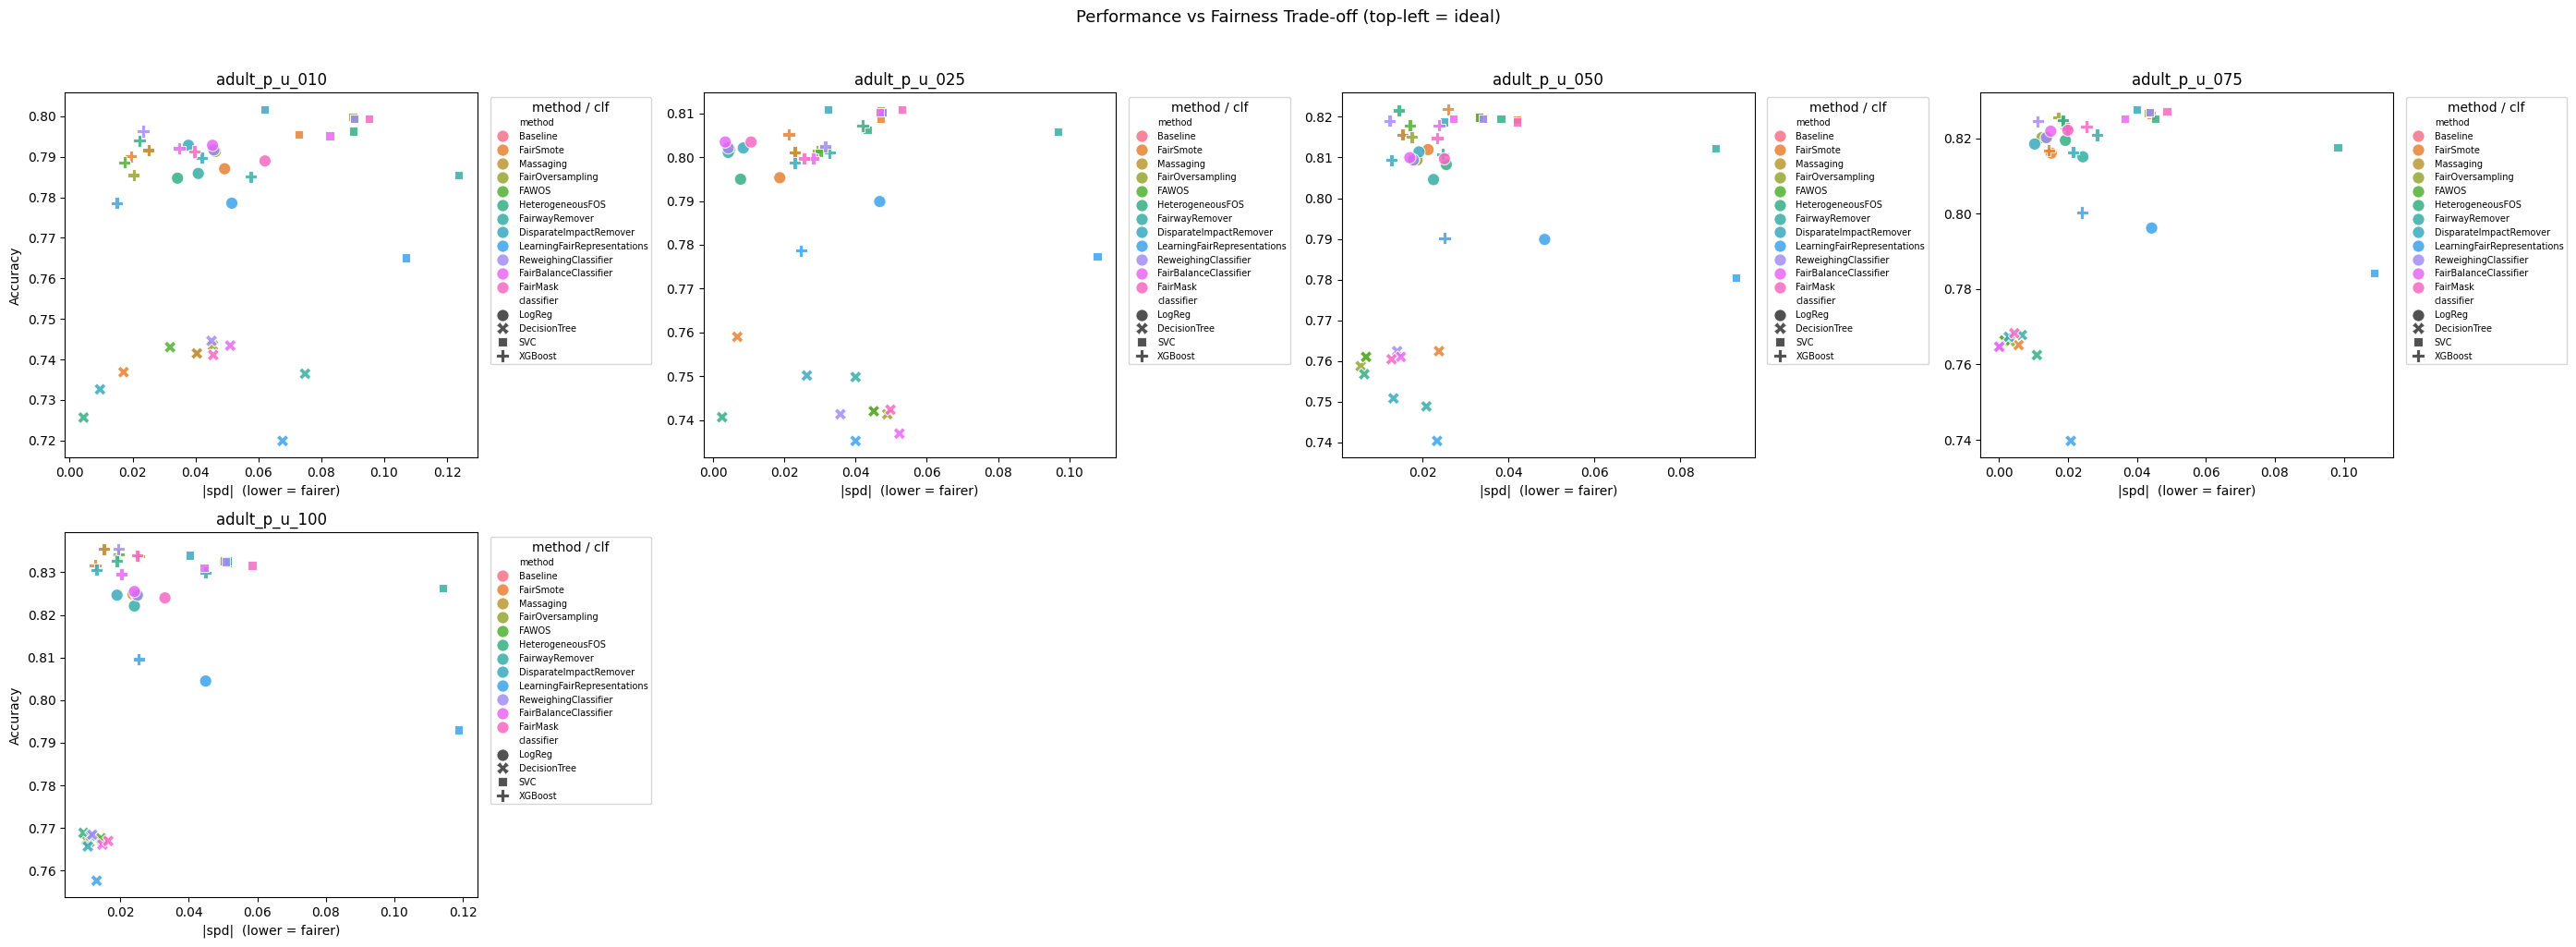

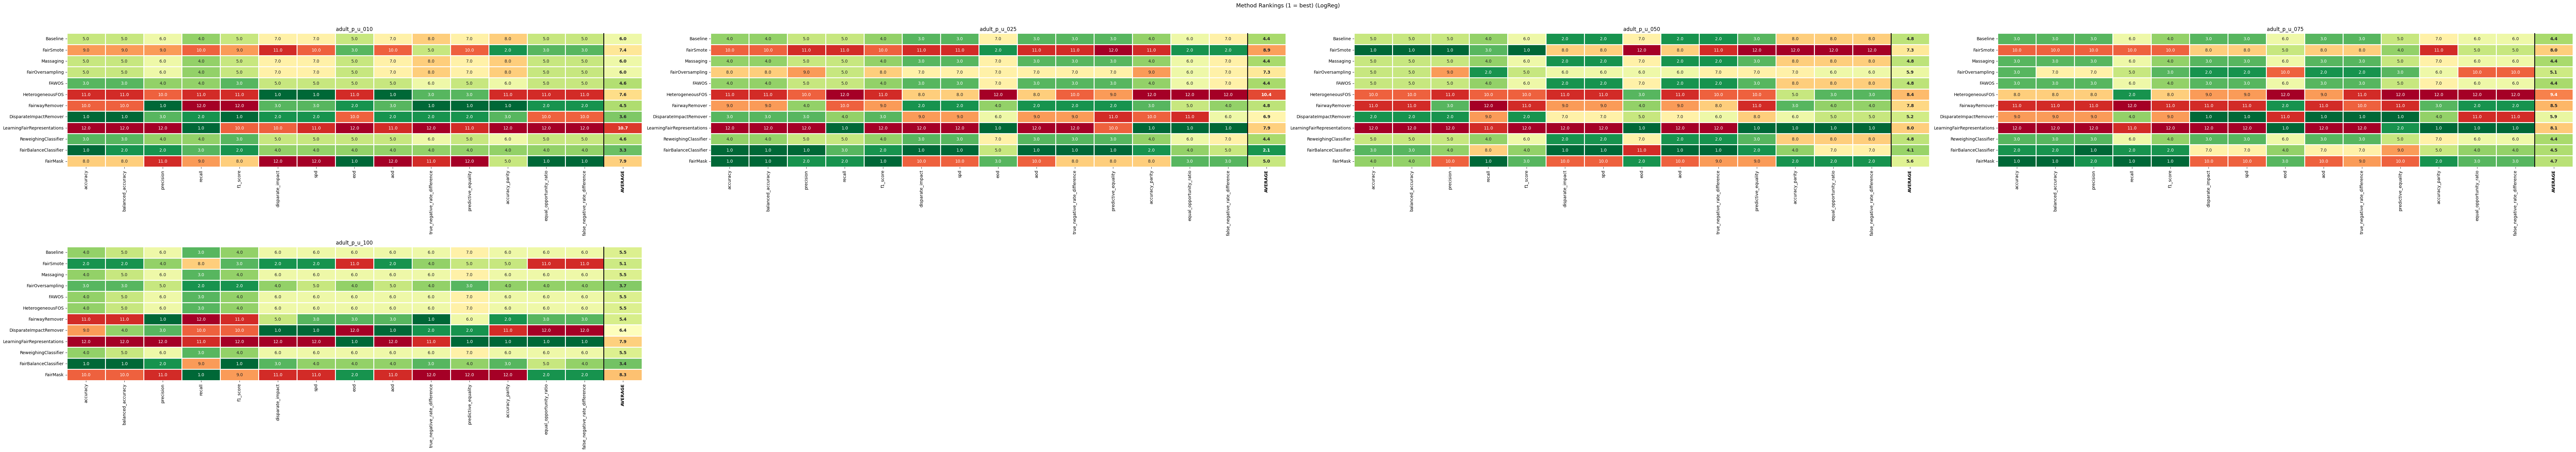

In [8]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");
report.plot_ranking(classifier="LogReg");

## 9. Headline view — fairness vs `p_u`

Parse `p_u` from the dataset name, then aggregate per (method, level). This is
the money chart: which methods hold fairness as the unprivileged group shrinks?
`Baseline` should worsen monotonically as `p_u` drops; preprocessing methods
that earn their keep should stay flatter.

In [9]:
df = results.copy()
df["p_u"] = df["dataset"].str.split("_p_u_").str[-1].astype(int) / 100

df.groupby(["method", "p_u"])[["spd", "disparate_impact", "eod", "accuracy"]].mean().round(3)

spd  disparate_impact    eod  accuracy
method                      p_u                                           
Baseline                    0.10 -0.051             0.904  0.015     0.781
                            0.25 -0.030             0.941  0.058     0.789
                            0.50 -0.018             0.966  0.054     0.801
                            0.75 -0.020             0.963  0.055     0.809
                            1.00 -0.026             0.952  0.050     0.815
DisparateImpactRemover      0.10 -0.038             0.928  0.015     0.779
                            0.25 -0.023             0.956  0.059     0.790
                            0.50 -0.018             0.967  0.053     0.798
                            0.75 -0.017             0.968  0.054     0.807
                            1.00 -0.021             0.961  0.054     0.814
FAWOS                       0.10 -0.046             0.912  0.020     0.781
                            0.25 -0.032             0.938  0.054     0.789
                            0.50 -0.019             0.965  0.053     0.802
                            0.75 -0.019             0.964  0.055     0.809
                            1.00 -0.027             0.949  0.048     0.815
FairBalanceClassifier       0.10 -0.054             0.898  0.006     0.781
                            0.25 -0.033             0.936  0.048     0.788
                            0.50 -0.021             0.960  0.052     0.802
                            0.75 -0.018             0.966  0.055     0.809
                            1.00 -0.026             0.951  0.050     0.813
FairMask                    0.10 -0.061             0.885  0.004     0.780
                            0.25 -0.035             0.932  0.055     0.789
                            0.50 -0.026             0.952  0.045     0.801
                            0.75 -0.025             0.954  0.049     0.810
                            1.00 -0.033             0.938  0.043     0.814
FairOversampling            0.10 -0.051             0.904  0.016     0.780
                            0.25 -0.033             0.937  0.054     0.789
                            0.50 -0.019             0.964  0.053     0.801
                            0.75 -0.019             0.964  0.056     0.810
                            1.00 -0.028             0.948  0.049     0.815
FairSmote                   0.10 -0.031             0.942  0.039     0.777
                            0.25 -0.023             0.955  0.056     0.792
                            0.50 -0.028             0.946  0.044     0.804
                            0.75 -0.020             0.962  0.055     0.806
                            1.00 -0.025             0.953  0.049     0.814
FairwayRemover              0.10 -0.074             0.861 -0.028     0.773
                            0.25 -0.043             0.920  0.040     0.789
                            0.50 -0.039             0.928  0.027     0.794
                            0.75 -0.036             0.936  0.039     0.805
                            1.00 -0.043             0.924  0.029     0.812
HeterogeneousFOS            0.10 -0.038             0.930  0.015     0.775
                            0.25 -0.024             0.955  0.060     0.787
                            0.50 -0.021             0.961  0.050     0.802
                            0.75 -0.018             0.966  0.055     0.808
                            1.00 -0.026             0.951  0.047     0.815
LearningFairRepresentations 0.10 -0.060             0.890  0.020     0.761
                            0.25 -0.055             0.901  0.019     0.770
                            0.50 -0.047             0.915  0.020     0.775
                            0.75 -0.049             0.912  0.017     0.780
                            1.00 -0.051             0.911  0.021     0.791
Massaging                   0.10 -0.051             0.904  0.015     0.781
                            0.25 -0.030             0.941  0.